In [209]:
import cupy as cp
import numpy as np
import time
from memory_profiler import memory_usage
import matplotlib.pyplot as plt


In [210]:
SEED = 42
cp.random.seed(SEED)

SPACE_DIM=2

N = 1_000
BOX_LENGTH = 1
TEMPERATURE = 1

DELTA_T = 1e-6



In [211]:
def compute_distance_square_matrix_cp(positions: cp.ndarray) -> cp.ndarray:
    r2 = cp.sum(positions * positions, axis=1)
    D2 = r2[:, None] + r2[None, :] - 2 * (positions @ positions.T)
    cp.fill_diagonal(D2, cp.inf) # Remove self interactions
    return D2

def compute_coulomb_energy_cp(charges: cp.ndarray, D2: cp.ndarray) -> cp.float32:
    energy = 0.5 * cp.sum((charges[:, None] * charges[None, :]) / D2)
    return energy

def compute_lennard_jones_energy_cp(D2: cp.ndarray) -> cp.float32:
    D8 = cp.power(D2, 4)
    energy = cp.sum(1 / D8)
    return energy

def compute_potential_energy_cp(positions: cp.ndarray, charges: cp.ndarray, masses: cp.ndarray) -> cp.float32:
    D2 = compute_distance_square_matrix_cp(positions)
    energy_coulomb = compute_coulomb_energy_cp(charges, D2)
    #energy_lj = compute_lennard_jones_energy_cp(D2)
    return energy_coulomb


In [212]:
def create_particles_cp(N_PARTICLES):

    positions = cp.random.uniform(0, BOX_LENGTH, size=(N_PARTICLES, SPACE_DIM))
    velocities = cp.random.uniform(0, 1, size=(N_PARTICLES, SPACE_DIM))
    mass = cp.random.uniform(0.1, 1.0, size=N_PARTICLES)
    charge = cp.sign(cp.random.uniform(-1.0, 1.0, size=N_PARTICLES))

    return positions, velocities, mass, charge

In [213]:
N_list = [N]


for N_PARTICLES in N_list:
    positions, velocities, masses, charges = create_particles_cp(N_PARTICLES)
    
    cp.cuda.Stream.null.synchronize()  # sincronizza GPU prima del timing
    start = time.time()
    energy = compute_potential_energy_cp(positions, charges, masses)
    cp.cuda.Stream.null.synchronize()  # sincronizza dopo il calcolo
    end = time.time()
    
    print(f"N={N_PARTICLES} particelle")
    print(f"Tempo GPU: {end - start:.6f} secondi")
    
    print(f"Tempo GPU: {(end - start)*10000/60:.6f} minuti")
    
    print(f"Energia Coulomb: {energy:.6f}")


N=1000 particelle
Tempo GPU: 0.001045 secondi
Tempo GPU: 0.174125 minuti
Energia Coulomb: 1455416.981731


(0.0, 1.0)

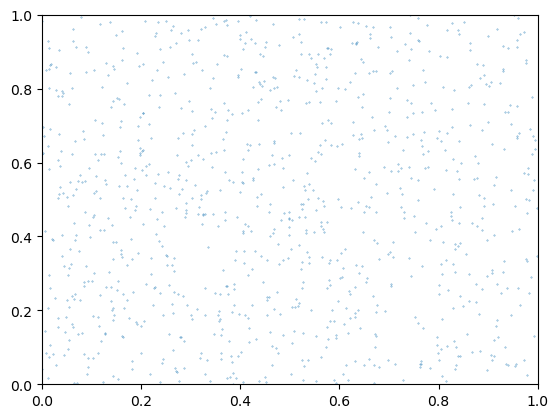

In [214]:
plt.scatter(cp.asnumpy(positions[:,0]), cp.asnumpy(positions[:,1]), s = 0.1, alpha=0.8)

plt.xlim([0,1])
plt.ylim([0,1])